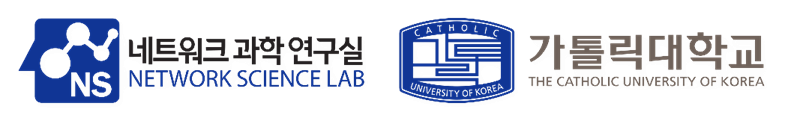

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W1/PracticeCode_1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Practice Code 1: Introduction to Graphs and NetworkX

Welcome to the first practice session for **Graph Neural Networks**. This notebook covers the basics of graphs, their representations, properties, centrality measures, and advanced graph algorithms like WL tests and Graph Kernels.

## Table of Contents
- [1. Setting Up Your Environment](#1.-Setting-Up-Your-Environment)
- [2. Import Libraries](#2.-Import-Libraries)
- [3. Components of a Network](#3.-Components-of-a-Network)
- [4. Undirected vs. Directed Graphs](#4.-Undirected-vs.-Directed-Graphs)
- [5. Graph Representations](#5.-Representing-Graphs:-Adjacency-Matrix)
- [6. Graph Connectivity and Properties](#7.-Connectivity-of-Undirected-Graph)
- [7. Centrality Measurements](#13.-Centrality-Measurement)
- [8. Advanced Graph Algorithms (Shortest Path, Kernels)](#15.-Shortest-path-between-2-nodes)

---


# 1. Setting Up Your Environment

How to setup environment:
- Download Anaconda and install: https://www.anaconda.com/products/distribution
- Create virtual environment
- Open the environment and install networkx
  - Install jupyter notebook: `pip install jupyter notebook`
  - Install networkx:  `pip install networkx`
  

> If you need a visual guide for installing and using **Conda and Jupyter Notebook**, please refer to the following tutorial:
> [Installing Anaconda and Using Jupyter Notebooks](https://plantsandpython.github.io/PlantsAndPython/00_PREFACE/02_Getting_started_Empezando/00_Installing_Anaconda.html)


# 2. Import libraries in the project

In [124]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Set beautiful style for plots
sns.set_theme(style='white', palette='muted')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# 3. Components of a Network

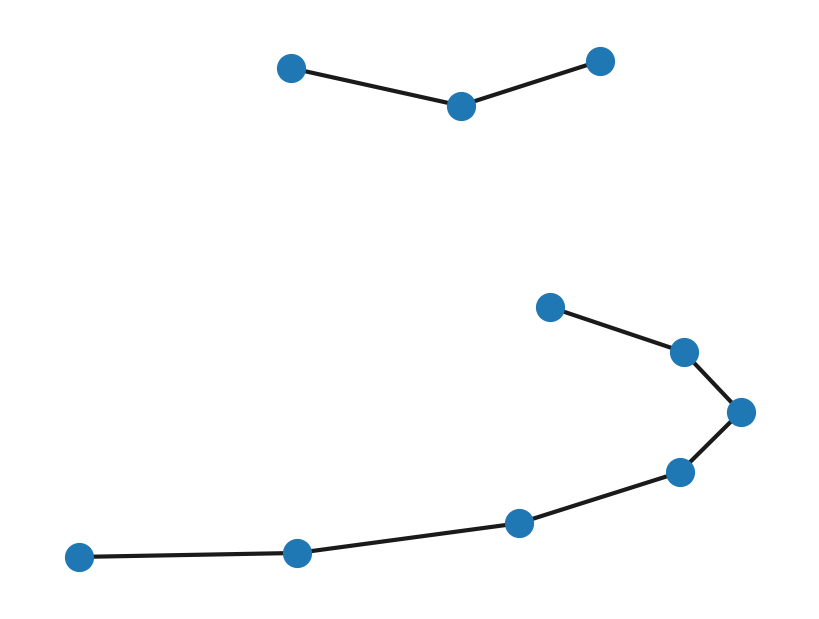

In [125]:
edge_list = [(0, 1), (0, 3), (1, 4), (2, 5), (3, 6), (4, 7), (5, 8), (6, 9)]
G = nx.Graph(edge_list)
nx.draw(G, node_color="tab:blue", node_size=400, width=3)
plt.show()

In [126]:
G.nodes

NodeView((0, 1, 3, 4, 2, 5, 6, 7, 8, 9))

In [127]:
G.edges

EdgeView([(0, 1), (0, 3), (1, 4), (3, 6), (4, 7), (2, 5), (5, 8), (6, 9)])

# 4. Undirected vs. Directed Graph

## 4.1. Undirected graph

In [128]:
G = nx.Graph()

### 4.1.1. Add nodes

In [129]:
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_node(5)
G.add_node(6)

### 4.1.2. Add edges

In [130]:
G.add_edge(1,2)
G.add_edge(3,1)
G.add_edge(2,4)
G.add_edge(4,1)
G.add_edge(5,1)
G.add_edge(1,6)
G.add_edge(6,2)

### 4.1.3. Draw

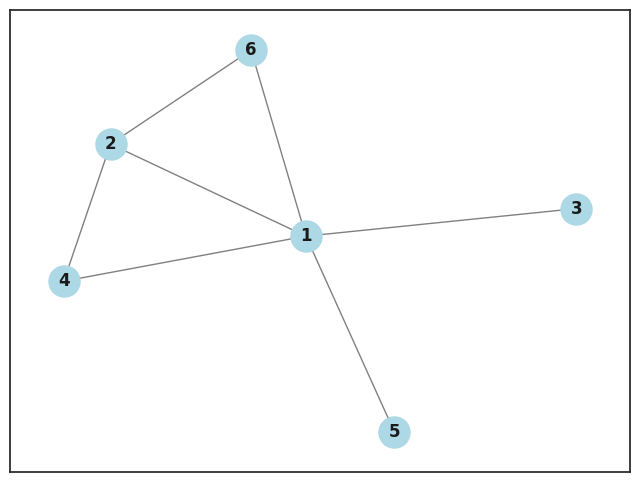

In [131]:
nx.draw_networkx(G, node_color='lightblue', node_size=500, edge_color='gray', font_size=12, font_weight='bold')

### 4.1.4. Add label in the node

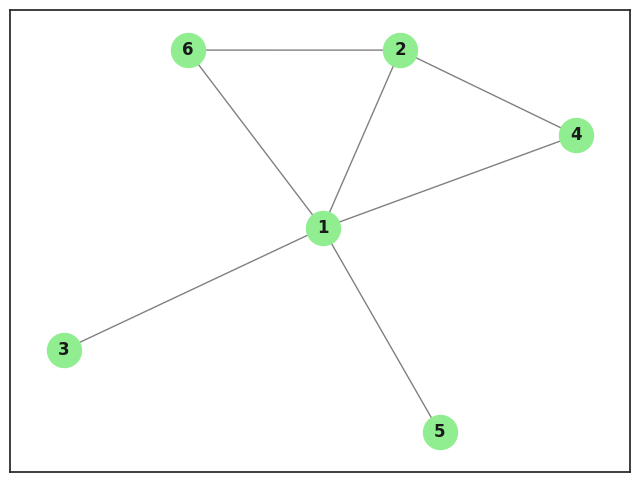

In [132]:
nx.draw_networkx(G, node_color='lightgreen', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

### 4.1.5. Get all nodes, edges of a graph

In [133]:
node_list = G.nodes()

print("Nodes:",node_list)
  
edge_list = G.edges()

print("Edges:",edge_list)

Nodes: [1, 2, 3, 4, 5, 6]
Edges: [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 4), (2, 6)]


### 4.1.6. Remove a node, edge of a graph

Node: [1, 2, 3, 5, 6]
Edge: [(1, 3), (1, 5), (1, 6), (2, 6)]


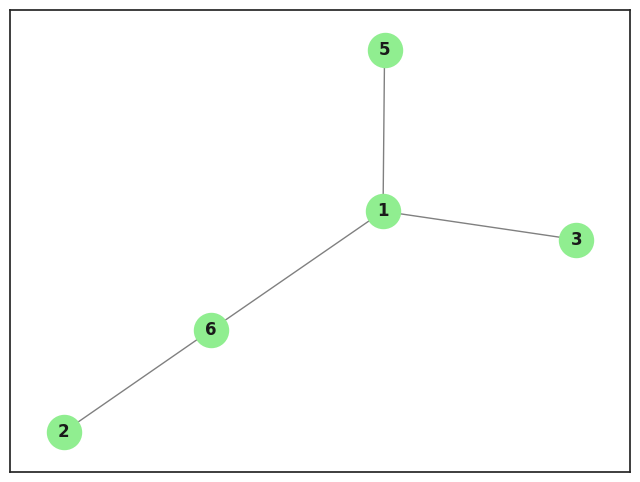

In [134]:
# Remove node 4
G.remove_node(4)
node_list = G.nodes()

print("Node:",node_list)

# Remove edge between node 1 and 2  
G.remove_edge(1,2)
edge_list = G.edges()

print("Edge:",edge_list)

nx.draw_networkx(G, node_color='lightgreen', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

### 4.1.7. Find number of nodes, edges

In [135]:
n = G.number_of_nodes()
print("Number of nodes:",n)

e = G.number_of_edges()
print("Number of edges:",e)

Number of nodes: 5
Number of edges: 4


### 4.1.8. Find neighbors of node

In [136]:
# Find neighbors of node 1
list(G.adj[1])

[3, 5, 6]

### 4.1.9. Degree of node

In [137]:
# The node degree is the number of edges adjacent to the node
G.degree[1] 

3

## 4.2. Create undirected graph from edge list

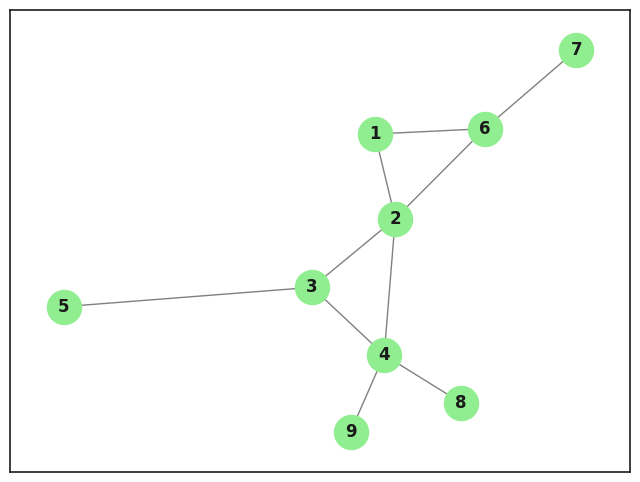

In [138]:
G = nx.Graph()

edges = [(1, 2, 5), (1, 6, 2), 
         (2, 3, 6), (2, 4, 3), (2, 6, 5), 
         (3, 4, 6), (3, 5, 1), 
         (4, 8, 9), (4, 9, 8), 
         (6, 7, 4)]

G.add_weighted_edges_from(edges)

nx.draw_networkx(G, node_color='lightgreen', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

## 4.3. Create directed graph from edge list

Number of nodes:  5
Number of edges:  8
List of nodes:  [1, 2, 4, 3, 5]
List of edges:  [(1, 2), (1, 4), (2, 3), (2, 4), (4, 3), (3, 5), (5, 4), (5, 1)]
In degree for nodes:  {1: 1, 2: 1, 4: 3, 3: 2, 5: 1}
Out degree for nodes:  {1: 2, 2: 2, 4: 1, 3: 1, 5: 2}


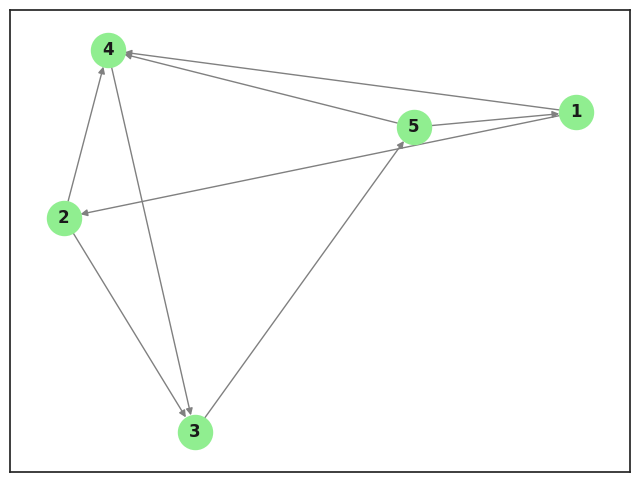

In [139]:
G = nx.DiGraph()

G.add_edges_from([(1, 2), (1, 4), 
                  (2, 3), (2, 4), 
                  (3, 5), 
                  (4, 3), 
                  (5, 4), (5, 1)])

# plt.figure(figsize =(4, 4))
nx.draw_networkx(G, node_color='lightgreen', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

print("Number of nodes: ", int(G.number_of_nodes()))
print("Number of edges: ", int(G.number_of_edges()))
print("List of nodes: ", list(G.nodes()))
print("List of edges: ", list(G.edges()))
print("In degree for nodes: ", dict(G.in_degree()))
print("Out degree for nodes: ", dict(G.out_degree))

## 4.4. Create weighted undirected graph from edge list

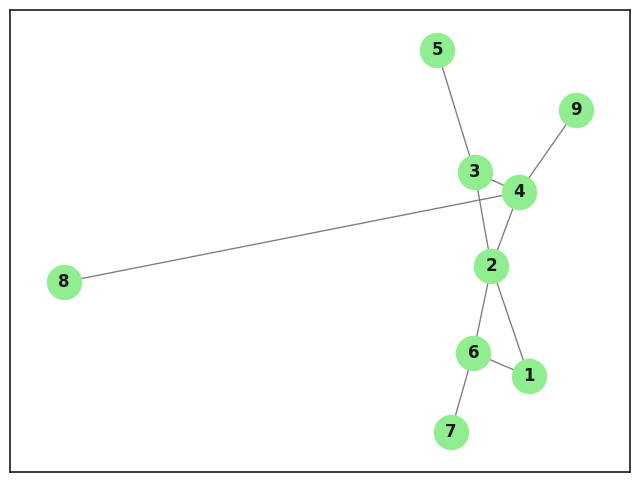

In [140]:
G = nx.Graph()
  
edges = [(1, 2, 2), (1, 6, 1), 
         (2, 3, 6), (2, 4, 7), (2, 6, 9), 
         (3, 4, 3), (3, 5, 2), 
         (4, 8, 0), (4, 9, 2), 
         (6, 7, 6)]
  
G.add_weighted_edges_from(edges)
nx.draw_networkx(G, node_color='lightgreen', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)


# 5. Representing Graphs: Adjacency Matrix

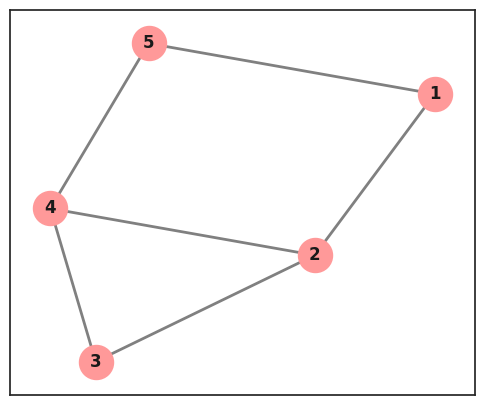


A:
[[0 1 1 0 0]
 [1 0 0 1 1]
 [1 0 0 0 1]
 [0 1 0 0 1]
 [0 1 1 1 0]]

ki: [[2 3 2 2 3]]
kj: [[2 3 2 2 3]]
# of edges (L): 6.0


In [141]:

edge_list = [(1, 2), (1, 5), (2, 3), (4, 3), (4,5), (2,4)]
G = nx.Graph(edge_list)
A = nx.adjacency_matrix(G).todense()
ki = A.sum(axis=0).flatten()
kj = A.sum(axis=1).flatten()
L = 0.5 * ki.sum()

plt.figure(figsize=(6, 5))
nx.draw_networkx(G, node_color='#ff9999', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)
plt.show()

print(f"\nA:\n{A}")
print(f"\nki: {ki}")
print(f"kj: {kj}")
print(f"# of edges (L): {L}")

# 6. Representing Graphs: Edge list

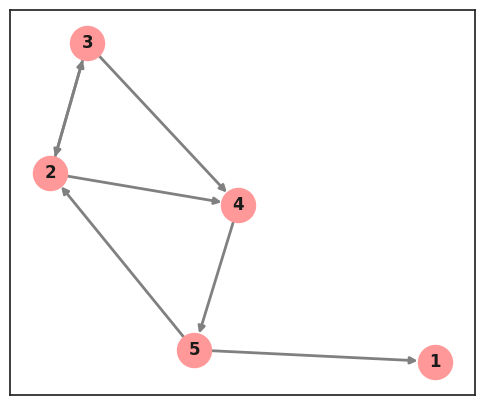

Edge list: [(2, 3), (2, 4), (3, 2), (3, 4), (4, 5), (5, 2), (5, 1)]


In [142]:
edge_list = [(2, 3), (2, 4), (3, 2), (3, 4), (4, 5), (5, 2), (5, 1)]
G = nx.DiGraph(edge_list)

plt.figure(figsize=(6, 5))
nx.draw_networkx(G, node_color='#ff9999', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)
A = nx.adjacency_matrix(G)
plt.show()

print(f"Edge list: {G.edges}")

# 7. Connectivity of Undirected Graph

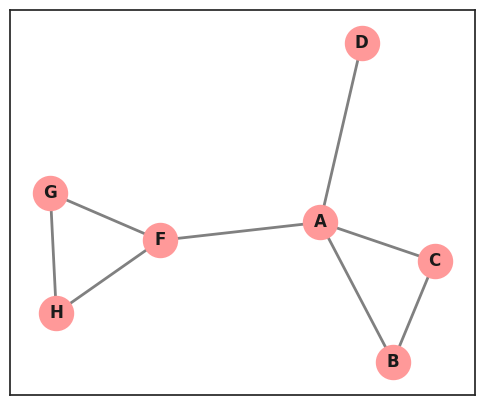

In [143]:
edge_list = [("A", "B"), ("A", "C"), ("A", "D"), ("A", "F"), ("B", "C"), ("F", "G"), ("F", "H"), ("G", "H")]
G = nx.Graph(edge_list)

plt.figure(figsize=(6, 5))
nx.draw_networkx(G, node_color='#ff9999', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)
plt.show()

# 8. Disconnect Connected Graph

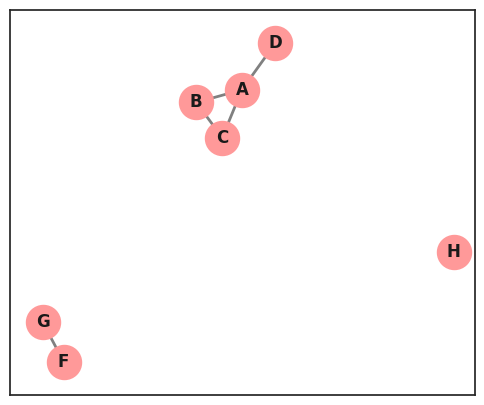

Giant Component: {'B', 'A', 'D', 'C'}
Isolated nodes: [{'H'}]


In [144]:

edge_list = [("A", "B"), ("A", "C"), ("A", "D"), ("B", "C"), ("F", "G")]
G = nx.Graph(edge_list)
G.add_node("H")
connected_components = sorted(nx.connected_components(G), key=len, reverse=True)
giant_component = connected_components[0]
isolated_nodes = [cc for cc in connected_components if len(cc) == 1]

plt.figure(figsize=(6, 5))
nx.draw_networkx(G, node_color='#ff9999', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)
plt.show()

print(f"Giant Component: {giant_component}")
print(f"Isolated nodes: {isolated_nodes}")

# 9. Bipartite graph

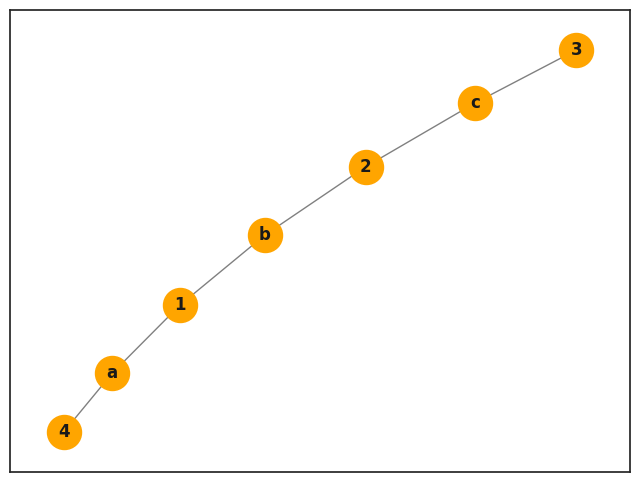

In [145]:
B = nx.Graph()

B.add_nodes_from([1, 2, 3, 4], bipartite=0)
B.add_nodes_from(["a", "b", "c"], bipartite=1)

B.add_edges_from([(1, "a"), (1, "b"), (2, "b"), (2, "c"), (3, "c"), (4, "a")])
nx.draw_networkx(B, node_color='orange', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

# 10. Diameter of the graph 

In [146]:
G = nx.Graph([(1, 2), (1, 3), (1, 4), (3, 4), (3, 5), (4, 5)])
nx.diameter(G)

3

# 11. Directed Acyclic Graph

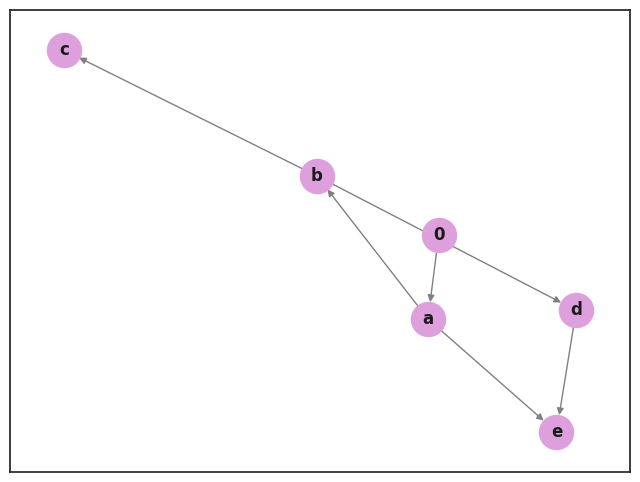

In [147]:
G = nx.DiGraph()
G.add_edges_from([("0", "a"), ("a", "b"), ("a", "e"), ("b", "c"), ("b", "d"), ("d", "e")])
nx.draw_networkx(G, node_color='plum', node_size=600, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

# 12. More Types of Graphs

## 12.1. Unweighted Graph

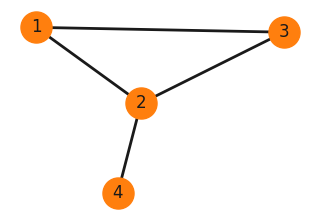


A:
[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [0 1 0 0]]

Avg. degree: 2.00


In [149]:
edge_list = [(1, 2), (1, 3), (2, 3), (2, 4)]
G = nx.Graph(edge_list)
A = nx.adjacency_matrix(G).todense()
E = A.sum() / 2
avg_degree = 2 * E / G.number_of_nodes()

plt.figure(figsize=(3, 2))
nx.draw(G, node_color="tab:orange", node_size=500, width=2, with_labels=True)
plt.show()

print(f"\nA:\n{A}")
print(f"\nAvg. degree: {avg_degree:.2f}")

## 12.2. Weighted Graph

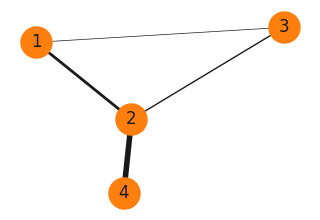


A:
[[0.  2.  0.5 0. ]
 [2.  0.  1.  4. ]
 [0.5 1.  0.  0. ]
 [0.  4.  0.  0. ]]

Avg. degree: 3.75


In [150]:
edge_list = [(1, 2, {"weight": 2}), (1, 3, {"weight": 0.5}), (2, 3, {"weight": 1}), (2, 4, {"weight": 4})]
G = nx.Graph(edge_list)
A = nx.adjacency_matrix(G).todense()
E = A.sum() / 2
avg_degree = 2 * E / G.number_of_nodes()

width = list(nx.get_edge_attributes(G, "weight").values())

plt.figure(figsize=(3, 2))
nx.draw(G, node_color="tab:orange", node_size=500, width=width, with_labels=True)
plt.show()

print(f"\nA:\n{A}")
print(f"\nAvg. degree: {avg_degree:.2f}")

# 13. Centrality Measurement

## 13.1. Degree Centrality

In [151]:
import numpy as np

A = np.array([[0,1,1,1,0,0,0,0,0],
              [1,0,1,0,0,0,0,0,0],
              [1,1,0,1,0,0,0,0,0],
              [1,0,1,0,1,1,0,0,0],
              [0,0,0,1,0,1,1,1,0],
              [0,0,0,1,1,0,1,1,0],
              [0,0,0,0,1,1,0,1,1],
              [0,0,0,0,1,1,1,0,0],
              [0,0,0,0,0,0,1,0,0]])
mat_size = len(A)
print("Size Graph: ", mat_size,":")
print(A)

Size Graph:  9 :
[[0 1 1 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0 0 0]
 [0 0 0 1 0 1 1 1 0]
 [0 0 0 1 1 0 1 1 0]
 [0 0 0 0 1 1 0 1 1]
 [0 0 0 0 1 1 1 0 0]
 [0 0 0 0 0 0 1 0 0]]


In [152]:
temp = A.copy()

def sum_of_row(graph, a):
    degSum = 0
    for column in range(mat_size):
        degSum += graph[a,column]
    return degSum
        
# Degree Centrality:
def degreeCentrality(a):
    degSum = sum_of_row(temp, a)
    result = (degSum/(mat_size-1))
    
    return result

In [153]:
DCValues = [degreeCentrality(a) for a in range(mat_size)]
print("Degree Centralities of the Graph: \n", DCValues)

Degree Centralities of the Graph: 
 [0.375, 0.25, 0.375, 0.5, 0.5, 0.5, 0.5, 0.375, 0.125]


In [154]:
H = nx.from_numpy_array(A)
DCValues = [degreeCentrality(a) for a in range(mat_size)]
print("Calculated Degree Centralities: \n", DCValues)
print("\nNetworkX Degree Centralities: \n", nx.degree_centrality(H))

Calculated Degree Centralities: 
 [0.375, 0.25, 0.375, 0.5, 0.5, 0.5, 0.5, 0.375, 0.125]

NetworkX Degree Centralities: 
 {0: 0.375, 1: 0.25, 2: 0.375, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5, 7: 0.375, 8: 0.125}


## 13.2. Betweenness Centrality

In [155]:
temp_Graph = nx.from_numpy_array(temp)

sigma = np.zeros((mat_size,mat_size))

min_lengths = np.zeros((mat_size,mat_size))

step_mat = np.zeros((mat_size,mat_size))

In [156]:
def step_betn_nodes(step_mat):
    for from_node in range(mat_size):
        for to_node in range(mat_size):
            lengthPath = nx.dijkstra_path_length(temp_Graph, from_node, to_node)
            #print("Path Length: ",lengthPath)
            step_mat[from_node][to_node] = lengthPath
            step_mat[to_node][from_node] = lengthPath

step_betn_nodes(step_mat)
print(step_mat)

pow_size = int(step_mat.max())+1
A_powers = [np.linalg.matrix_power(A,m) for m in range(1,pow_size)]

[[0. 1. 1. 1. 2. 2. 3. 3. 4.]
 [1. 0. 1. 2. 3. 3. 4. 4. 5.]
 [1. 1. 0. 1. 2. 2. 3. 3. 4.]
 [1. 2. 1. 0. 1. 1. 2. 2. 3.]
 [2. 3. 2. 1. 0. 1. 1. 1. 2.]
 [2. 3. 2. 1. 1. 0. 1. 1. 2.]
 [3. 4. 3. 2. 1. 1. 0. 1. 1.]
 [3. 4. 3. 2. 1. 1. 1. 0. 2.]
 [4. 5. 4. 3. 2. 2. 1. 2. 0.]]


In [157]:
for i in range(mat_size):
    for j in range(mat_size):
        for x in range(pow_size-1):
            X = A_powers[x].copy()
            if X[i,j] > 0 and i != j:
                sigma[i,j] = X[i,j]
                min_lengths[i,j] = x + 1
                break

In [158]:
def sigma_through_jay(j):
    # Number of shortest paths through node j
    B = A.copy()
    B[j] = np.zeros(mat_size)
    B[:,j] = np.zeros(mat_size)
    B_powers = [np.linalg.matrix_power(B,m) for m in [1,2,3,4,5]] ##[1,2,3,4,5]]
    B_sigma = np.zeros((mat_size,mat_size))
    B_min_lengths = np.zeros((mat_size,mat_size))
    for i in range(mat_size):
        for k in range(mat_size):
            if i != k:
                X = B_powers[int(min_lengths[i,k]-1)]
                B_sigma[i,k] = X[i,k]
    return (sigma - B_sigma)

In [159]:
def betweenness_centrality(j):
    # Finally, the betweenness
    sigst = sigma_through_jay(j)
    total = 0
    for i in range(mat_size):
        for k in range(i):
            if i != j and k != j:
                total += sigst[i,k] / sigma[i,k]
    # We return a single number.
    return total

In [160]:
betweennessCentralityValues = [betweenness_centrality(x) for x in range(mat_size)]
print("Betweenness Centralities of the Graph: \n", betweennessCentralityValues)

Betweenness Centralities of the Graph: 
 [3.0, 0.0, 3.0, 15.0, 6.0, 6.0, 7.0, 0.0, 0.0]


In [161]:
betweenness = nx.betweenness_centrality(H, normalized=False).values()
print("Betweenness Centrality:", betweenness)

Betweenness Centrality: dict_values([3.0, 0.0, 3.0, 15.0, 6.0, 6.0, 7.0, 0.0, 0.0])


## 13.3. Closeness Centrality

In [162]:
# Calculate the shortest path:
import networkx as nx
import numpy as np

# Converting it to a NetworkX Graph:
temp_Graph = nx.from_numpy_array(temp)

# Creating a blank Step Matrix 
step_mat = np.zeros((mat_size,mat_size))
# Calculate between nodes and save it in the step matrix:
def step_betn_nodes(step_mat):
    for from_node in range(mat_size):
        for to_node in range(mat_size):
            lengthPath = nx.dijkstra_path_length(temp_Graph, from_node, to_node)
            #print("Path Length: ",lengthPath)
            step_mat[from_node][to_node] = lengthPath
            step_mat[to_node][from_node] = lengthPath

step_betn_nodes(step_mat)
print(step_mat)

def closenessCentrality(b):
    closeSum = sum_of_row(step_mat, b)
    
    # dividing the (n-1) nodes
    result = ((mat_size-1)/closeSum)
    
    return result

[[0. 1. 1. 1. 2. 2. 3. 3. 4.]
 [1. 0. 1. 2. 3. 3. 4. 4. 5.]
 [1. 1. 0. 1. 2. 2. 3. 3. 4.]
 [1. 2. 1. 0. 1. 1. 2. 2. 3.]
 [2. 3. 2. 1. 0. 1. 1. 1. 2.]
 [2. 3. 2. 1. 1. 0. 1. 1. 2.]
 [3. 4. 3. 2. 1. 1. 0. 1. 1.]
 [3. 4. 3. 2. 1. 1. 1. 0. 2.]
 [4. 5. 4. 3. 2. 2. 1. 2. 0.]]


In [163]:
closenessCentralityValues = [closenessCentrality(b) for b in range(mat_size)]
print("Closeness Centralities: \n", closenessCentralityValues)

Closeness Centralities: 
 [0.47058823529411764, 0.34782608695652173, 0.47058823529411764, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.5, 0.47058823529411764, 0.34782608695652173]


In [164]:
print("\nNetworkX Closeness: \n", nx.closeness_centrality(H))


NetworkX Closeness: 
 {0: 0.47058823529411764, 1: 0.34782608695652173, 2: 0.47058823529411764, 3: 0.6153846153846154, 4: 0.6153846153846154, 5: 0.6153846153846154, 6: 0.5, 7: 0.47058823529411764, 8: 0.34782608695652173}


## 13.4. Eigenvector Centrality

In [165]:
# Calculating Eigens of the graph
w,v = np.linalg.eig(temp)
# Index of the Maximum Absolute Eigen Value of the graph
index = (np.abs(max(w, key=abs))).argmax()

# Eigen Vector of the maximum Eigen Value
eigenCentralityValues = [v[ecv,index] for ecv in range(mat_size)]

print("Eigen Vector Centralities of the Graph: \n", eigenCentralityValues)

Eigen Vector Centralities of the Graph: 
 [0.1957487957091835, 0.11168370323986566, 0.19574879570918338, 0.3787480253356783, 0.4680854763104227, 0.46808547631042285, 0.40997938953295365, 0.3840203838411054, 0.11695606174529301]


In [166]:
nx.eigenvector_centrality(H)

{0: 0.1957540414970864,
 1: 0.1116880543296416,
 2: 0.19575404149708636,
 3: 0.378751077373384,
 4: 0.4680839101306905,
 5: 0.4680839101306905,
 6: 0.4099765880693859,
 7: 0.3840179229632457,
 8: 0.11695489991950335}

## 13.5. Katz Centrality

In [167]:
# Converting it to a NetworkX Graph:
G_temp = nx.from_numpy_array(temp)
# nx.draw_networkx(G_temp, node_color='cyan', node_size=500, edge_color='gray', font_weight='bold')

In [168]:
#default value
alpha = 1
beta = 1
max_iter = 1000
tol = 1e-06
weight = None

nx.katz_centrality(G_temp)

{0: 0.32231142220857734,
 1: 0.2893349955974206,
 2: 0.32231142220857734,
 3: 0.36274091133772884,
 4: 0.367029925075744,
 5: 0.367029925075744,
 6: 0.3577487271446689,
 7: 0.33405349846458715,
 8: 0.26064758272427896}

In [169]:
from math import sqrt
b = dict.fromkeys(G_temp,float(beta))

def Katz(G, alpha=0.1, beta=1.0, max_iter=1000, tol=1.0e-6):
    nnodes = G.number_of_nodes()
    dict_v = dict([(n,0) for n in G])
    b = dict.fromkeys(G,float(beta))
    for i in range(max_iter):
        xlast = dict_v
        dict_v = dict.fromkeys(xlast, 0)
        # y^T = anfa * x^T A - b
        for n in dict_v:
            for nbr in G[n]:
                dict_v[nbr] += xlast[n] * G[n][nbr].get(weight, 1)
        for n in dict_v:
            dict_v[n] = alpha*dict_v[n] + b[n]
        err = sum([abs(dict_v[n]-xlast[n]) for n in dict_v])
        if err < nnodes*tol:
            # normalize 
            s = 1.0/sqrt(sum(v**2 for v in dict_v.values()))
            s= np.round(s,3)
            for n in dict_v:
                dict_v[n] *= s
                dict_v[n] = np.round(dict_v[n],3)
            return dict_v
Katz(G_temp)

{0: 0.322,
 1: 0.289,
 2: 0.322,
 3: 0.363,
 4: 0.367,
 5: 0.367,
 6: 0.358,
 7: 0.334,
 8: 0.261}

## 13.6. PageRank Centrality

In [170]:
import numpy as np
import scipy as sp

def Pagerank(G,alpha=0.85, max_iter=100,tol=1.0e-6):
    
    N = len(G)
    nodelist = list(G)
    # A = nx.to_scipy_sparse_array(G, nodelist=nodelist, dtype=float)
    A = nx.to_scipy_sparse_matrix(G, nodelist=nodelist, dtype=float)
    # S = A.sum(axis=1)
    S = np.asarray(A.sum(axis=1))
    S[S != 0] = 1.0 / S[S != 0]
    Q = sp.sparse.csr_array(sp.sparse.spdiags(S.T, 0, *A.shape))
    A = Q @ A
    # initial vector
    x = np.repeat(1.0 / N, N)
    p = np.repeat(1.0 / N, N)
    
    dangling_weights = p
    is_dangling = np.where(S == 0)[0]
    for _ in range(max_iter):
        xlast = x
        x = alpha * (x @ A + sum(x[is_dangling]) * dangling_weights) + (1 - alpha) * p
        #l1 norm
        err = np.absolute(x - xlast).sum()
        if err < N * tol:
            return dict(zip(nodelist, map(float, np.round(x,4))))

In [171]:
Pagerank(G)

{1: 0.18, 2: 0.4445, 3: 0.1221, 4: 0.2534}

In [172]:
from networkx.algorithms.link_analysis.pagerank_alg import pagerank

pagerank(G, alpha=0.85, personalization=None, max_iter=100, tol=1e-06, nstart=None, weight='weight', dangling=None)


{1: 0.1800368225891517,
 2: 0.444488122917579,
 3: 0.12207995080293223,
 4: 0.253395103690337}

# 14. Sparse and dense adjacency matrix of a direct graph

In [173]:
# Instantiate the graph
G = nx.DiGraph()
# add node/edge pairs
G.add_edges_from([(0, 1), (0, 2), (0, 3), (0, 4), (1, 3), (1, 6), (3, 4), (4, 5), (4, 7), (5, 8), (8, 9)])


A = nx.adjacency_matrix(G)
print("The sparse adjacency matrix: ")
print(A)

print("The dense adjacency matrix: ")
A_dense = A.todense()
print(A_dense)

# Pandas format
nx.to_pandas_adjacency(G)

The sparse adjacency matrix: 
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (1, 3)	1
  (1, 5)	1
  (3, 4)	1
  (4, 6)	1
  (4, 7)	1
  (6, 8)	1
  (8, 9)	1
The dense adjacency matrix: 
[[0 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]]


,0,1,2,3,4,6,5,7,8,9
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 15. Shortest path between 2 nodes

Shortest path from 0 -> 9: 
0->3->4->5->8->9


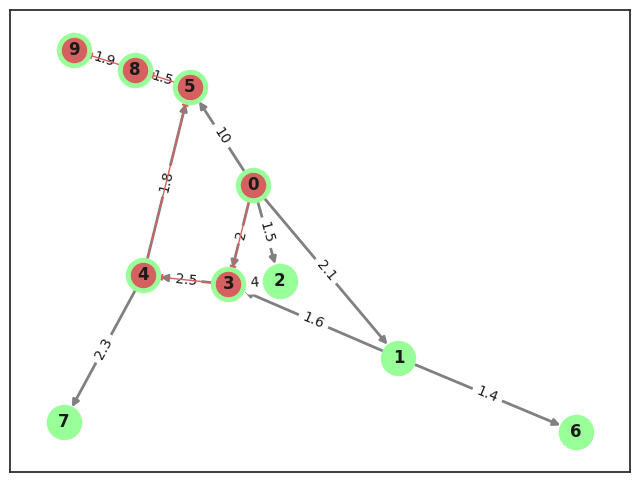

In [174]:
# Instantiate the graph
G = nx.DiGraph()

edges = [(0, 1, 2.1), (0, 2, 1.5), (0, 3, 2), (0, 5, 10), (1, 3, 1.6), (1, 6, 1.4), (2, 3, 4), (3, 4, 2.5), (4, 5, 1.8), (4, 7, 2.3), (5, 8, 1.5), (8, 9, 1.9)]
# add node/edge pairs
G.add_weighted_edges_from(edges)

# Pandas format
nx.to_pandas_adjacency(G)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, node_color='#99ff99', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)
# draw path in red

source = 0
target = 9
path = nx.shortest_path(G,source=source,target=target, weight='weight', method="dijkstra")

print(f"Shortest path from {source} -> {target}: ")
print("->".join(map(str, path)))

path_edges = list(zip(path,path[1:]))
nx.draw_networkx_nodes(G,pos,nodelist=path,node_color='r')

labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='r')

# 16. Weisfeiler Lehman (WL) graph hash

## 16.1. Initialize graphs

In [175]:
G1 = nx.Graph()
G1.add_edges_from(
    [
        (1, 2, {"label": "A"}),
        (2, 3, {"label": "A"}),
        (3, 1, {"label": "A"}),
        (1, 4, {"label": "B"}),
    ]
)
G1_node_attributes = {
    1: "A",
    2: "B",
    3: "C",
    4: "D",
}
# Set node labels by using node attributes
nx.set_node_attributes(G1, G1_node_attributes, name="label")

G2 = nx.Graph()
G2.add_edges_from(
    [
        (5, 6, {"label": "B"}),
        (6, 7, {"label": "A"}),
        (7, 5, {"label": "A"}),
        (7, 8, {"label": "A"}),
    ]
)
G2_node_attributes = {
    5: "E",
    6: "F",
    7: "G",
    8: "H",
}
# Set node labels by using node attributes
nx.set_node_attributes(G2, G2_node_attributes, name="label")


{1: 'A', 2: 'B', 3: 'C', 4: 'D'}


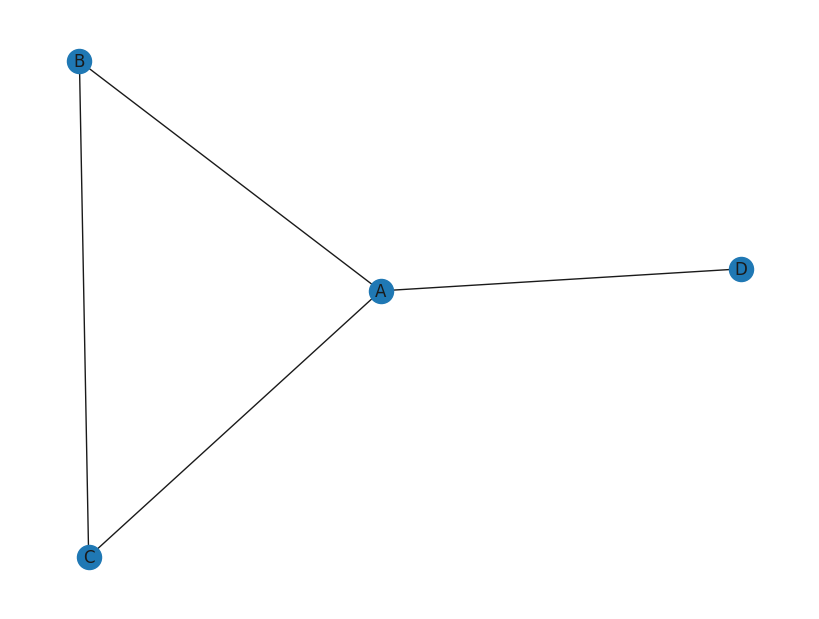

In [176]:
def draw_graph_with_labels(graph):
    labels = dict()
    names = nx.get_node_attributes(graph, 'label')
    print(names)
    for node in graph.nodes:
        labels[node] = f"{names[node]}"
    nx.draw(graph, labels=labels)
    

draw_graph_with_labels(G1)

{5: 'E', 6: 'F', 7: 'G', 8: 'H'}


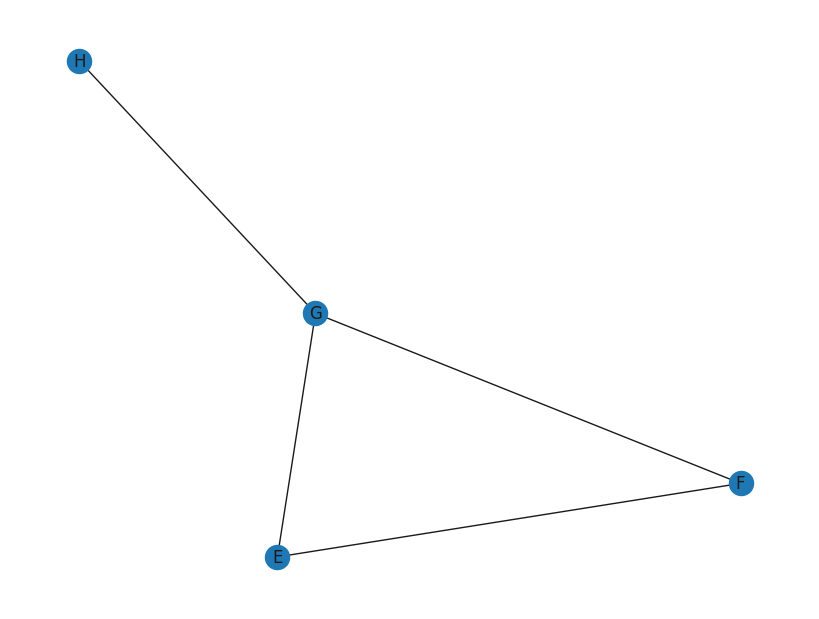

In [177]:
draw_graph_with_labels(G2)

## 16.2. Without labels

In [178]:
from collections import Counter

"""
Functions for hashing graphs to strings.
Isomorphic graphs should be assigned identical hashes.
For now, only Weisfeiler-Lehman hashing is implemented.
"""
from hashlib import blake2b

def _hash_label(label, digest_size):
    return blake2b(label.encode("ascii"), digest_size=digest_size).hexdigest()

def _init_node_labels(G, edge_attr, node_attr):
    if node_attr:
        return {u: str(dd[node_attr]) for u, dd in G.nodes(data=True)}
    elif edge_attr:
        return {u: "" for u in G}
    else:
        return {u: str(deg) for u, deg in G.degree()}

def _neighborhood_aggregate(G, node, node_labels, edge_attr=None):
    """
    Compute new labels for given node by aggregating
    the labels of each node's neighbors.
    """
    label_list = []
    for nbr in G.neighbors(node):
        prefix = "" if edge_attr is None else str(G[node][nbr][edge_attr])
        label_list.append(prefix + node_labels[nbr])
    return node_labels[node] + "".join(sorted(label_list))

def weisfeiler_lehman_graph_hash(
    G, edge_attr=None, node_attr=None, iterations=3, digest_size=16
):
    def weisfeiler_lehman_step(G, labels, edge_attr=None):
        """
        Apply neighborhood aggregation to each node
        in the graph.
        Computes a dictionary with labels for each node.
        """
        new_labels = {}
        for node in G.nodes():
            label = _neighborhood_aggregate(G, node, labels, edge_attr=edge_attr)
            new_labels[node] = _hash_label(label, digest_size)
        return new_labels

    # set initial node labels
    node_labels = _init_node_labels(G, edge_attr, node_attr)

    subgraph_hash_counts = []
    for _ in range(iterations):
        node_labels = weisfeiler_lehman_step(G, node_labels, edge_attr=edge_attr)
        counter = Counter(node_labels.values())
        # sort the counter, extend total counts
        subgraph_hash_counts.extend(sorted(counter.items(), key=lambda x: x[0]))

    # hash the final counter
    return _hash_label(str(tuple(subgraph_hash_counts)), digest_size)

In [179]:
g1_hash = weisfeiler_lehman_graph_hash(G1)
g2_hash = weisfeiler_lehman_graph_hash(G2)

# g1_hash and g2_hash are equal when they are isomorphic
print(f"First  graph hash: {g1_hash}")
print(f"Second graph hash: {g2_hash}")
print(f"Checking graph isomorphic: {g1_hash==g2_hash}")

First  graph hash: 7bc4dde9a09d0b94c5097b219891d81a
Second graph hash: 7bc4dde9a09d0b94c5097b219891d81a
Checking graph isomorphic: True


## 16.3. With edge labels

In [180]:
g1_hash = weisfeiler_lehman_graph_hash(G1, edge_attr="label")
g2_hash = weisfeiler_lehman_graph_hash(G2, edge_attr="label")

# g1_hash and g2_hash are equal when they are isomorphic
print(f"First  graph hash: {g1_hash}")
print(f"Second graph hash: {g2_hash}")
print(f"Checking graph isomorphic: {g1_hash==g2_hash}")

First  graph hash: c653d85538bcf041d88c011f4f905f10
Second graph hash: 3dcd84af1ca855d0eff3c978d88e7ec7
Checking graph isomorphic: False


## 16.4. WL implementation
It contains different methods to construct the WL-Test and k-WL-Test.

### 16.4.1. Implement the method to generate the WL-Test
<!-- ![image info](./data/WL.png) -->
**Algorithm** *1-WL (color refinement)*  
**Input:** $G = (V, E, X_V)$  
1. $c_v^0 \leftarrow \text{hash}(X_v) \text{ for all } v \in V$  
2. **repeat**  
3. $\quad c_v^\ell \leftarrow \text{hash}(c_v^{\ell-1}, \{\!\!\{ c_w^{\ell-1} : w \in \mathcal{N}_G(v) \}\!\!\}) \ \forall v \in V$  
4. **until** $(c_v^\ell)_{v \in V} = (c_v^{\ell-1})_{v \in V}$  
5. **return** $\{\!\!\{ c_v^\ell : v \in V \}\!\!\}$


The set of elements are the nodes of the graph. 

The initial color is the same for everybody and is only the ‘1’ string, and finally, its neighborhood is only the connected nodes to the node of interest.

In [181]:
import hashlib
import copy
import itertools

# A base function to calculate WL
def compute_base_WL(graph, k, verbose, n_set, initial_colors_func, find_neighbors_func):    
    G, n = n_set(graph)
    colors = initial_colors_func(n)
    old_colors = copy.deepcopy(colors)
    
    for i in range(len(n)):
        for node in n:
            neigh_colors = "".join([colors[i][0] for i in find_neighbors_func(G, n, node)])
            colors[node].extend([neigh_colors])
            colors[node].sort()
            
        # Update with the hash
        colors = {i: [hashlib.sha224("".join(colors[i]).encode('utf-8')).hexdigest()] for i in colors}
        
        if list(Counter([item for sublist in colors.values() for item in sublist]).values()) == list(Counter([item for sublist in old_colors.values() for item in sublist]).values()) and i != 0:
            if verbose:
                print(f'Converged at iteration {i}!')
            break
        
        old_colors = copy.deepcopy(colors)
    canonical_form = sorted(Counter([item for sublist in colors.values() for item in sublist]).items())
    
    if verbose:
        print(f'Canonical Form Found: \n {canonical_form} \n')
        
    return canonical_form


In [182]:
def WL(G, k=2, verbose=False):
    # The function to generate the graph with set of nodes in integer labels
    def n_set(G):
        G = nx.convert_node_labels_to_integers(G)
        return G, list(G.nodes())
    
    # The function to initialize colors for nodes
    def set_initial_colors(n):
        return {i: [hashlib.sha224("1".encode('utf-8')).hexdigest()] for i in n}
    
    # The function to check neighbors of a node
    def find_neighbors(G, n, node):
        return G.neighbors(node)
    
    # Compute WL test
    return compute_base_WL(G, k, verbose, n_set, set_initial_colors, find_neighbors)


### 16.4.2. Compute k-WL
The k-dimensional Weisfeiler Lehman test extends the test to coloring k-tuples of nodes.

<!-- ![image info](./data/kWL.png) -->
**Algorithm** *1-WL (color refinement)*  
**Input:** $G = (V, E, X_V)$  
1. $c_v^0 \leftarrow \text{hash}(X_v) \text{ for all } v \in V$  
2. **repeat**  
3. $\quad c_v^\ell \leftarrow \text{hash}(c_v^{\ell-1}, \{\!\!\{ c_w^{\ell-1} : w \in \mathcal{N}_G(v) \}\!\!\}) \ \forall v \in V$  
4. **until** $(c_v^\ell)_{v \in V} = (c_v^{\ell-1})_{v \in V}$  
5. **return** $\{\!\!\{ c_v^\ell : v \in V \}\!\!\}$


#### The differences from the WL-Test:

- The set of elements is based on V^k and not on V anymore.

- The initial color is not the same for every node, now it depends on the nodes that compose the element
- The neighborhood of each element is defined according to bellow equation.

<!-- ![image info](./data/kWL_eq.png) -->
$\mathcal{N}_i(\vec{v}) = \{(v_1, \dots, v_{i-1}, w, v_{i+1}, \dots, v_k) : w \in V\}.$

In [183]:
def kWL(G, k, verbose=False):
    def n_set(G):
        G = nx.convert_node_labels_to_integers(G)
        V = list(G.nodes())
        
        # Considering node with k-tuples of nodes
        V_k = [comb for comb in itertools.combinations(V, k)]
        return G, V_k

    def set_initial_colors(n):
        return {i: [hashlib.sha224(str(i).encode('utf-8')).hexdigest()] for i in n}

    # Find k-hop neighbors
    def find_neighbors(G, V_k, node):
        return [n for n in V_k if len(set(n) - set(V_k[V_k.index(node)])) == 1]

    return compute_base_WL(G, k, verbose, n_set, set_initial_colors, find_neighbors)

In [184]:
def check_graph_isomorphic(G1, G2, method='WL', k=2, verbose=False):
    methods = {
        'WL': WL,
        'kWL': kWL
    }

    # If two graphs have different numbers of nodes they cannot be isomorphic
    if len(G1.nodes()) != len(G2.nodes()):
        if verbose:
            print('Non-Isomorphic by different number of nodes!')
        return False
    
    g1_hash = methods[method](G1, k, verbose)
    g2_hash = methods[method](G2, k, verbose)

    print(f"Checking graph isomorphic: {g1_hash==g2_hash}")
    return

### 16.4.3. Compute k-WL
Comparing the graph on the left L and the graph on the right R

<!-- ![image info](./data/example_isomorphic.png) -->
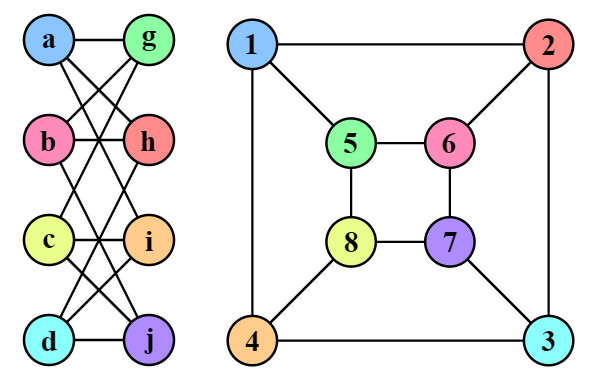

In [112]:
# Create graph L
L = nx.Graph(
    [
        ("a", "g"),
        ("a", "h"),
        ("a", "i"),
        ("g", "b"),
        ("g", "c"),
        ("b", "h"),
        ("b", "j"),
        ("h", "d"),
        ("c", "i"),
        ("c", "j"),
        ("i", "d"),
        ("d", "j"),
    ]
)

# Create graph R
R = nx.Graph(
    [
        (1, 2),
        (1, 5),
        (1, 4),
        (2, 6),
        (2, 3),
        (3, 7),
        (3, 4),
        (4, 8),
        (5, 6),
        (5, 8),
        (6, 7),
        (7, 8),
    ]
)

check_graph_isomorphic(R, L, k=1, verbose=True, method='WL')

Converged at iteration 1!
Canonical Form Found: 
 [('9f43c972c6d21dec7641f34208d88a86d8cd791a839d8ae95cac66e7', 8)] 

Converged at iteration 1!
Canonical Form Found: 
 [('9f43c972c6d21dec7641f34208d88a86d8cd791a839d8ae95cac66e7', 8)] 

Checking graph isomorphic: True


### 16.4.4. Test k-WL with k = 3

In [113]:
check_graph_isomorphic(R, L, k=2, verbose=True, method='kWL')

Converged at iteration 1!
Canonical Form Found: 
 [('03cd0379aec8717d03c0431e5963bc6953492d4cf6a15a3e2e9dea45', 1), ('0c6b9ecbf69916fcd99d8aaaeb8919785245647ad294290a81999b0c', 1), ('0fb6a4170702a2f2556f9b2f178ce20dd36b8dc008253f0054bec42b', 1), ('17931a26071743dd0164a4e1fa6c5b2b7427b0494d71d1346f1063a6', 1), ('27d2517f4a598b0ecc8a86c13c4cc7e0c3e1a21f111b1f4750eba680', 1), ('2ab6c5f96589faaafa4e0c6f5b5cfd8ed67044dba6cccdfcb032d785', 1), ('36ea5314d1355aea4bdadbb1fbc4541ce81144a43f92d13d2c2847ba', 1), ('3833b3af52de3ae2dd433c68ba2ae1d8b2f035ab35b300870d56ea12', 1), ('4205be6c27a2b9584d1ca133393d0893804f5416a9b557863edf80c9', 1), ('492031c674a1b333800d6ba4a33e4bf0029c591a66a7469251e62e0f', 1), ('4f52e044162c6c06a19acbf86457b170526991a6777a86995d7c1412', 1), ('5443c3d2dffd6e9f500591d82a018a4d4173e426c09fe9b85ca17347', 1), ('5ddecb48972d7bb3a16ccca24aeb38057b7ba0beefed39beee424ca2', 1), ('70bffeed5d01986b673191d61a3186c559277fca5641d31617d47a82', 1), ('71b8ad49e4177385565afb91e77218120482d

# 17. WL Subtree Kernel

WL subtree kernel value: 6


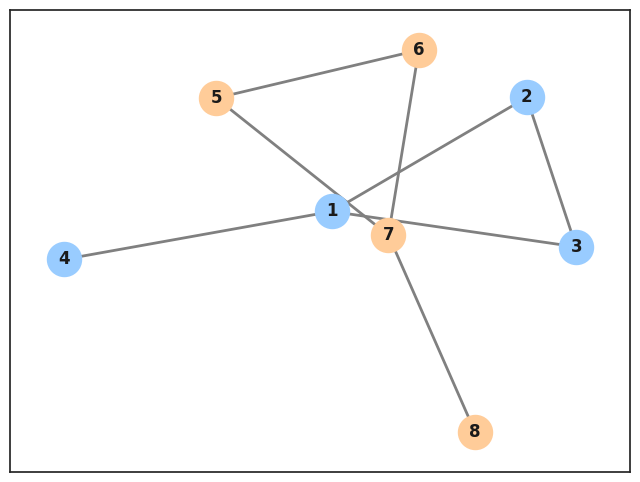

In [114]:
import networkx as nx
import numpy as np

def weisfeiler_lehman_subtree_kernel(G1, G2, h):
    """
    Compute the Weisfeiler-Lehman subtree kernel between two graphs.

    Parameters:
        G1 (networkx.Graph): The first input graph.
        G2 (networkx.Graph): The second input graph.
        h (int): The number of iterations in the Weisfeiler-Lehman algorithm.

    Returns:
        float: The similarity score between the two graphs.
    """
    # Compute the node labels using the initial degree as the label
    labels1 = {node: [G1.degree(node)] for node in G1.nodes()}
    labels2 = {node: [G2.degree(node)] for node in G2.nodes()}

    for i in range(h):
        # Update node labels based on the multiset of labels in the neighborhood
        new_labels1 = {}
        new_labels2 = {}
        for node in G1.nodes():
            neighbors_labels = sorted(labels1[n] for n in G1.neighbors(node))
            new_labels1[node] = labels1[node] + neighbors_labels
        for node in G2.nodes():
            neighbors_labels = sorted(labels2[n] for n in G2.neighbors(node))
            new_labels2[node] = labels2[node] + neighbors_labels
        labels1 = new_labels1
        labels2 = new_labels2

    # Compute the kernel value by comparing label distributions
    kernel_value = 0
    for label1 in labels1.values():
        for label2 in labels2.values():
            if label1 == label2:
                kernel_value += 1

    return kernel_value

# Define two simple graphs
G1_nx = nx.path_graph(4)
nx.set_node_attributes(G1, {0:'a', 1:'b', 2:'c', 3:'d'}, 'label')
nx.draw_networkx(G1, node_color='#99ccff', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)

G2_nx = nx.path_graph(4)
nx.set_node_attributes(G2, {0:'a', 1:'a', 2:'b', 3:'c'}, 'label')
nx.draw_networkx(G2, node_color='#ffcc99', node_size=600, width=2, edge_color='gray', font_size=12, font_weight='bold', with_labels=True)


kernel_value = weisfeiler_lehman_subtree_kernel(G1, G2, h=2)
print("WL subtree kernel value:", kernel_value)


# 18. Pyramid Match (PM) graph kernel: 
Embeds the vertices of the input graphs in a vector space. 

It then partitions the feature space into regions of increasingly larger size and takes a weighted sum of the matches that occur at each level.

In [115]:
import networkx as nx
import numpy as np

def pyramid_match_kernel(G1, G2, levels):
    """
    Compute the Pyramid Match graph kernel between two graphs.

    Parameters:
        G1 (networkx.Graph): The first input graph.
        G2 (networkx.Graph): The second input graph.
        levels (int): The number of levels in the pyramid decomposition.

    Returns:
        float: The similarity score between the two graphs.
    """
    # Extract node and edge attributes for each graph
    node_attrs_G1 = nx.get_node_attributes(G1, 'attribute')
    node_attrs_G2 = nx.get_node_attributes(G2, 'attribute')
    edge_attrs_G1 = nx.get_edge_attributes(G1, 'weight')
    edge_attrs_G2 = nx.get_edge_attributes(G2, 'weight')

    # Initialize kernel matrix
    kernel_matrix = np.zeros((levels, levels))

    # Perform pyramid decomposition and compute similarity at each level
    for level in range(levels):
        # Extract features for current level
        features_G1 = extract_features(G1, node_attrs_G1, edge_attrs_G1, level)
        features_G2 = extract_features(G2, node_attrs_G2, edge_attrs_G2, level)

        # Compute similarity between feature vectors
        similarity = compute_similarity(features_G1, features_G2)

        # Update kernel matrix
        kernel_matrix[level, level] = similarity

    # Aggregate similarities from all levels
    kernel_value = np.sum(kernel_matrix)

    return kernel_value

def extract_features(G, node_attrs, edge_attrs, level):
    """
    Extract features for a given level of the pyramid decomposition.

    Parameters:
        G (networkx.Graph): The input graph.
        node_attrs (dict): Node attributes of the graph.
        edge_attrs (dict): Edge attributes of the graph.
        level (int): The current level of the pyramid decomposition.

    Returns:
        numpy.ndarray: Feature vector for the given level.
    """
    # Extract node and edge features based on the level
    # (This is a simplified example, actual feature extraction may be more complex)
    node_features = [attr for node in G.nodes() for attr in node_attrs[node]]
    edge_features = [edge_attrs[edge] for edge in G.edges()]

    # Concatenate node and edge features into a single feature vector
    features = np.concatenate((node_features, edge_features))

    return features

def compute_similarity(features_G1, features_G2):
    """
    Compute similarity between feature vectors.

    Parameters:
        features_G1 (numpy.ndarray): Feature vector of graph G1.
        features_G2 (numpy.ndarray): Feature vector of graph G2.

    Returns:
        float: Similarity score between the two feature vectors.
    """
    # Compute similarity between feature vectors (e.g., using cosine similarity)
    similarity = np.dot(features_G1, features_G2) / (np.linalg.norm(features_G1) * np.linalg.norm(features_G2))

    return similarity

# Define two simple graphs
G1 = nx.Graph()
G1.add_edge(1, 2, weight=0.5)
G1.add_edge(2, 3, weight=0.8)
G1.nodes[1]['attribute'] = [0.1, 0.2]
G1.nodes[2]['attribute'] = [0.3, 0.4]
G1.nodes[3]['attribute'] = [0.5, 0.6]

G2 = nx.Graph()
G2.add_edge(1, 2, weight=0.6)
G2.add_edge(2, 3, weight=0.7)
G2.nodes[1]['attribute'] = [0.1, 0.2]
G2.nodes[2]['attribute'] = [0.3, 0.4]
G2.nodes[3]['attribute'] = [0.5, 0.6]

kernel_value = pyramid_match_kernel(G1, G2, levels=3)
print("Pyramid Match graph kernel value:", kernel_value)


Pyramid Match graph kernel value: 2.9833343913998465


# 19. Random Walk Kernel

In [116]:
import networkx as nx
import random

def random_walk_kernel(graph1, graph2, walk_length=2, num_walks=20):
    # Initialize the kernel to zero
    kernel = 0

    # Perform random walks on both graphs
    for _ in range(num_walks):
        # Perform a random walk on the first graph
        walk1 = random_walk(graph1, walk_length)

        # Perform a random walk on the second graph
        walk2 = random_walk(graph2, walk_length)

        # Update the kernel if the walks have common subsequences
        if walk1 == walk2:
            kernel += 1

    # Normalize the kernel
    kernel /= num_walks

    return kernel

def random_walk(graph, walk_length):
    # Start the walk at a random node
    node = random.choice(list(graph.nodes()))

    # Perform the random walk
    walk = [node]
    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(node))
        if neighbors:
            node = random.choice(neighbors)
            walk.append(node)
        else:
            break

    return tuple(walk)

# Define two simple graphs
G1 = nx.Graph([(1, 2), (2, 3), (3, 4), (4, 1)])
G2 = nx.Graph([(1, 2), (2, 3), (3, 4)])

walk_length = 2
num_walks = 20
kernel_value = random_walk_kernel(G1, G2, walk_length, num_walks)
print("Random Walk Kernel Value:", kernel_value)


Random Walk Kernel Value: 0.0


# 20. Graphlet Kernel

In [117]:
import networkx as nx
import numpy as np
from itertools import combinations

def compute_graphlet_counts(G, k):
    """
    Compute the counts of k-node graphlets in the given graph.

    Parameters:
        G (networkx.Graph): The input graph.
        k (int): The size of the graphlets to count.

    Returns:
        dict: A dictionary containing the counts of k-node graphlets.
    """
    graphlet_counts = {graphlet: 0 for graphlet in range(1, k+1)}

    for node in G.nodes():
    # Generate the induced subgraph with node and its neighbors
        subgraph_nodes = [node] + list(G.neighbors(node))
        subgraph = G.subgraph(subgraph_nodes)

        # Count the occurrences of k-node graphlets in the subgraph
        for graphlet_size in range(1, k+1):
            for subgraph_nodes_subset in combinations(subgraph_nodes, graphlet_size):
                if G.subgraph(subgraph_nodes_subset).number_of_nodes() == graphlet_size:
                    graphlet_counts[graphlet_size] += 1

    return graphlet_counts

def compute_graphlet_kernel(G1, G2, k):
    """
    Compute the graphlet kernel between two graphs.

    Parameters:
        G1 (networkx.Graph): The first input graph.
        G2 (networkx.Graph): The second input graph.
        k (int): The size of the graphlets to count.

    Returns:
        float: The similarity score between the two graphs.
    """
    # Compute the counts of k-node graphlets in each graph
    graphlet_counts_G1 = compute_graphlet_counts(G1, k)
    graphlet_counts_G2 = compute_graphlet_counts(G2, k)

    # Compute the kernel value by comparing the counts of graphlets
    kernel_value = 0
    for graphlet in range(1, k+1):
        kernel_value += min(graphlet_counts_G1[graphlet], graphlet_counts_G2[graphlet])

    return kernel_value

# Define two simple graphs
G1 = nx.Graph([(1, 2), (2, 3), (3, 4), (4, 1)])
G2 = nx.Graph([(1, 2), (2, 3), (3, 4)])

k = 3  # Size of the graphlets to count

kernel_value = compute_graphlet_kernel(G1, G2, k)
print("Graphlet kernel value:", kernel_value)


Graphlet kernel value: 20
